##Introduction

Sabrina and I are Microbiology majors who have both served as teaching assistants for **MCB3023L**, a core Microbiology lab course at UF. One of the biggest components of this course — and definitely the most scary — is the **lab practical**, which is long, detailed, and a major part of the student's grade. A lot of students struggle with it, and we were curious:  
**What factors actually influence how well students do on the lab practical?**

So we made it our project focus. We wanted to investigate patterns that might explain performance on the practical, with the ultimate goal of helping **our professor and her future students**. (Because Professor Bacusmo has done a lot for us! To us, she is the GOAT!!!)

## Data Collection & Survey Distribution

We designed an anonymous survey specifically targeting students in MCB3023L. The survey asked about things like:

- How closely they paid attention in lab  
- Whether they came in to practice outside of scheduled hours, and how often they did so 
- How confident or anxious they felt going into the exam  
- How many hours they studied  
- And how helpful they found different study tools (like the lab manual, Quizlet, ChatGPT, etc.)  


We also asked whether they had prior lab experience — and, most importantly, what **letter grade** they received on the lab practical.  

To give you an idea of what the students took, here is the survey: 

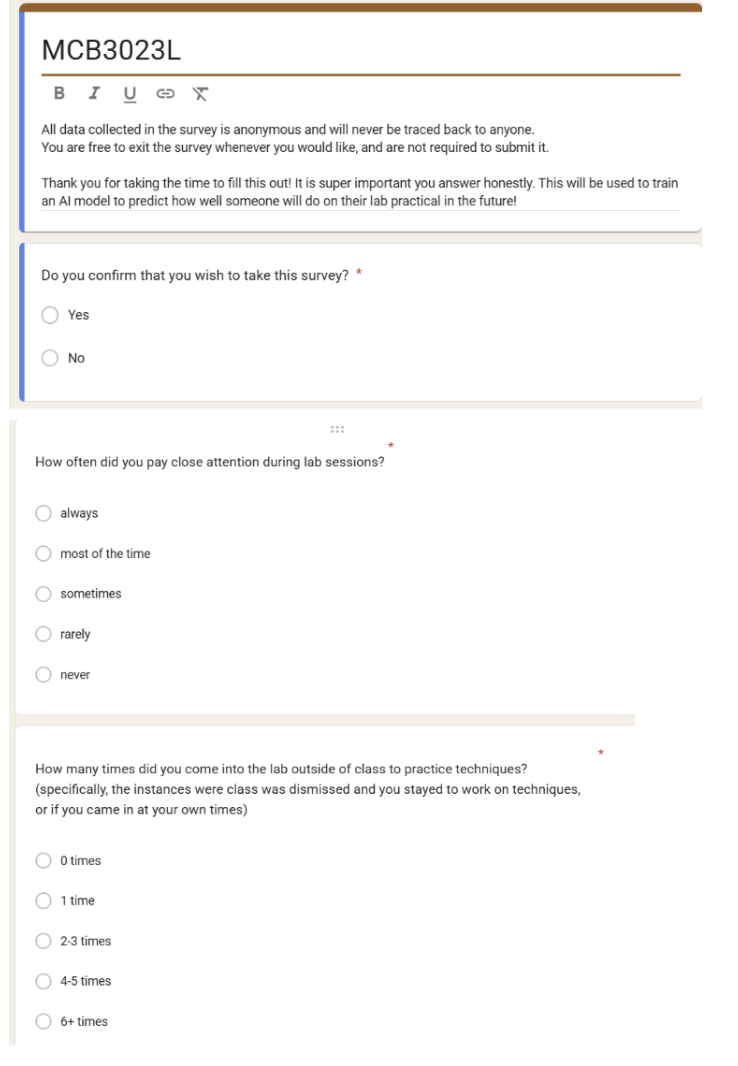

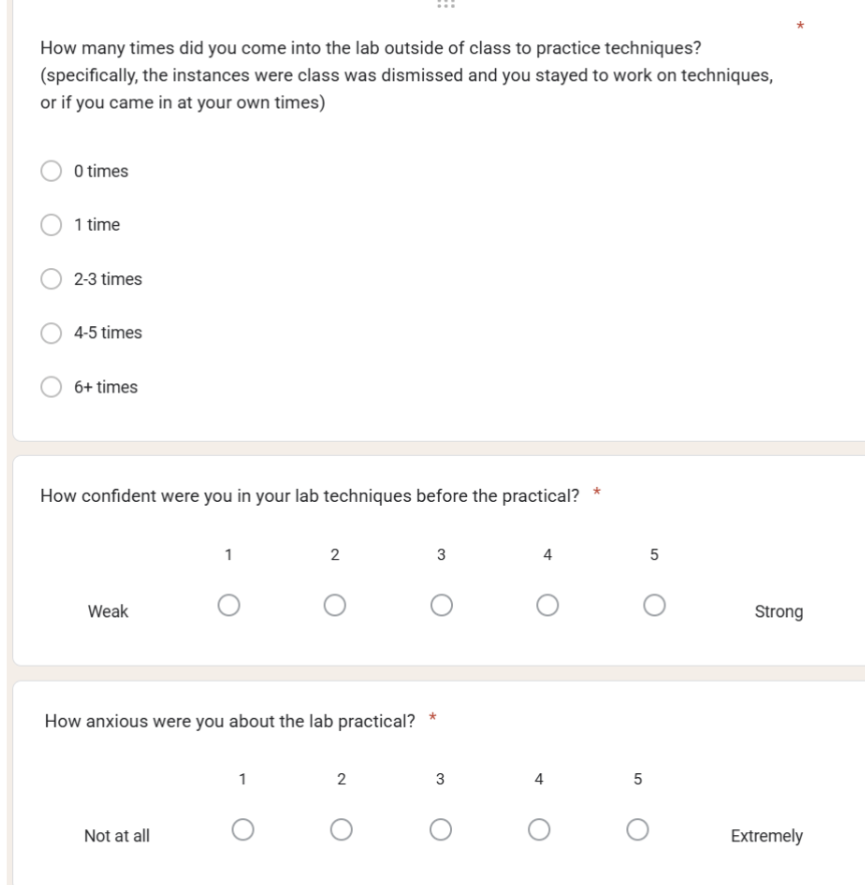

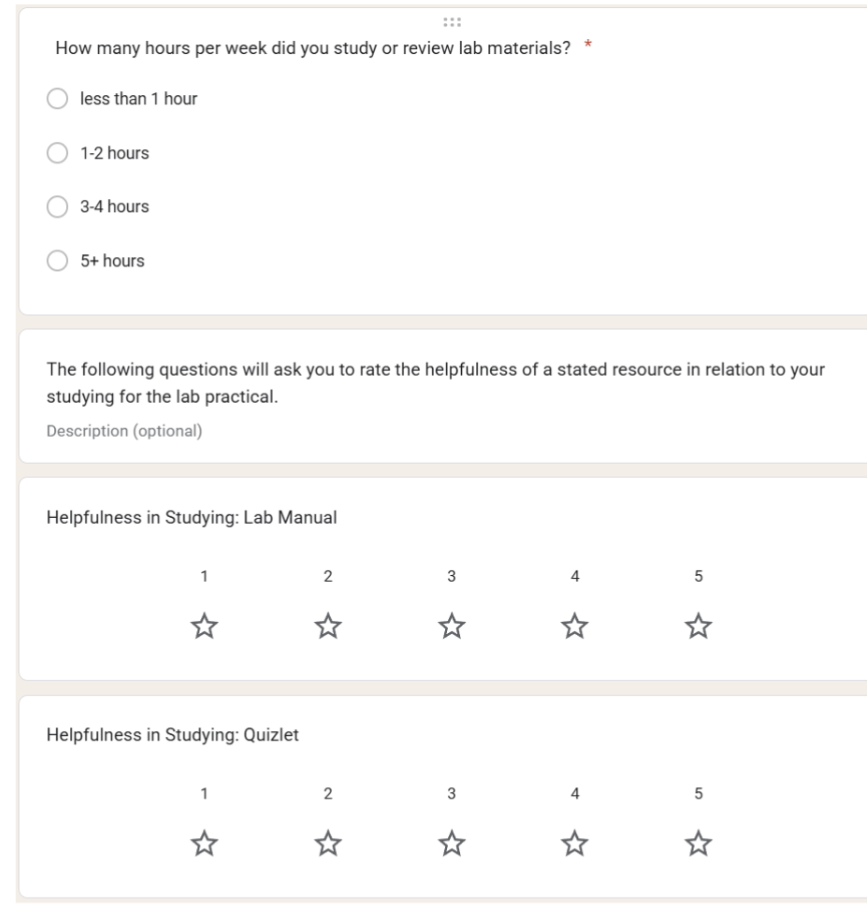

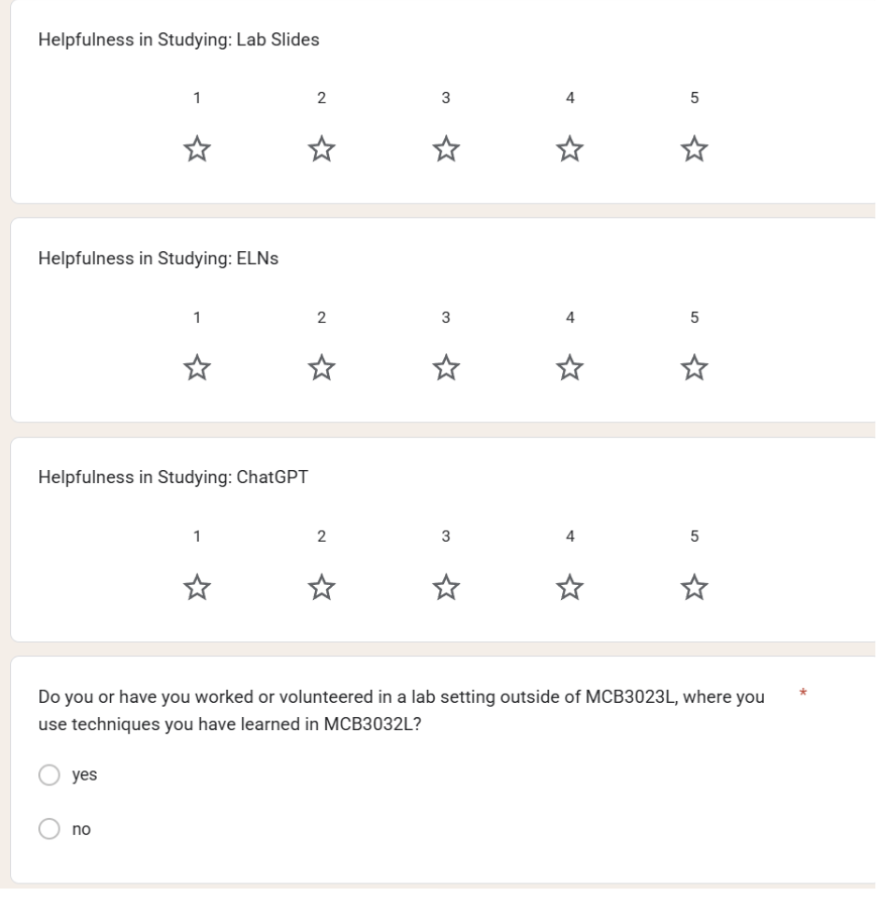

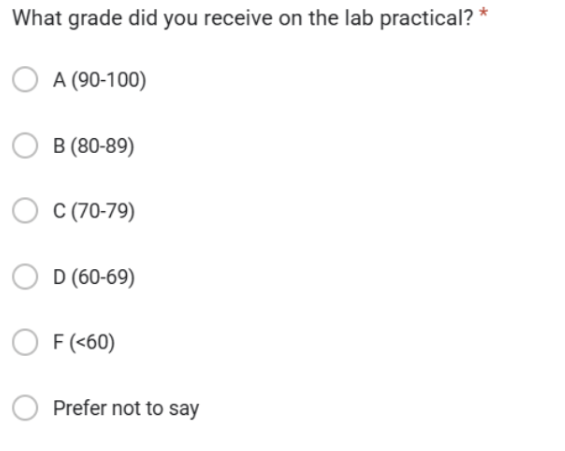

To stay on the ethical side of things, we got **IRB exemption and faculty sponsorship** before distributing the survey. Even though this wasn’t for publication, we wanted to do things right just in case.

Then we reached out to **three professors who teach MCB3023L** and asked them to share the survey with their students. That was honestly the most important step because without data,there is basically no project to do.

We ended up getting **82 responses total**. Was it the massive sample size we hoped for? No. We ran into email response problems with one of the professors, which is understandable because she is very busy. We at least got two of the professors to distribute the survey.

This just taught us that real-world data collection doesn’t always go the way you plan. We worked with what we had.

## The Question

Can we predict a student’s **lab practical grade** using their **study habits, lab confidence, anxiety, and resource usage**?


## Methods

Since we didn’t have a huge dataset, we ruled out using deep learning or anything that needs a ton of training data. Instead, we focused on models that are more reasonable for smaller datasets and still meaningful:

- **Logistic Regression** – a simple baseline that helps show which features are important
- **Decision Tree Classifier** – good for picking up non-linear patterns in the data
- **Random Forest** – combines multiple trees to improve accuracy and reduce overfitting
- **Gradient Boosting** – builds on the idea of decision trees by focusing on correcting previous errors

We trained each model to predict a student’s **letter grade** (A, B, C, D, or F) using their survey responses — including things like study habits, confidence, anxiety, and how useful they found certain resources.


## Data Pre-processing

Before we could do anything with the data, we had to clean it up and make it usable for modeling.


# Step 1: Loading the Data + Cleaning Columns

We started by loading our survey responses from the CSV file. The original column names were way too long to work with, so we renamed them to shorter and more readable names.

We also removed two columns:  
- `timestamp` → not helpful for modeling  
- `survey_confirmation` → just a checkbox that didn’t provide useful data

Then we dropped any rows where students selected “Prefer not to say” for their grade. Since the grade is our **target variable**, there's not much we can do with those responses.

In [5]:
import pandas as pd

# Load the raw CSV file
df = pd.read_csv("MCB3032L (Responses) - Form Responses final.csv")

# Rename columns to something more readable
df.columns = [
    "timestamp",
    "attention_during_lab",
    "lab_practice_times",
    "confidence_before_practical",
    "anxiety_about_practical",
    "study_hours_per_week",
    "helpfulness_lab_manual",
    "helpfulness_quizlet",
    "helpfulness_lab_slides",
    "helpfulness_eln",
    "helpfulness_chatgpt",
    "prior_lab_experience",
    "lab_practical_grade",
    "survey_confirmation"
]

# Drop unnecessary columns
df = df.drop(columns=["timestamp", "survey_confirmation"], errors="ignore")

# Drop "Prefer not to say" rows from grade column. Why? If this is the target variable, and the person did not answer, the rest of their data is not very useful to us. 
df = df[df["lab_practical_grade"].str.strip().str.lower() != "prefer not to say"]

# Display the first few rows
df.head()


,attention_during_lab,lab_practice_times,confidence_before_practical,anxiety_about_practical,study_hours_per_week,helpfulness_lab_manual,helpfulness_quizlet,helpfulness_lab_slides,helpfulness_eln,helpfulness_chatgpt,prior_lab_experience,lab_practical_grade
0,most of the time,0 times,5,3,less than 1 hour,3.0,1.0,4.0,5,1.0,yes,A (90-100)
1,most of the time,2-3 times,5,2,1-2 hours,1.0,1.0,2.0,1,1.0,yes,D (60-69)
2,most of the time,2-3 times,4,2,1-2 hours,3.0,1.0,5.0,5,4.0,yes,B (80-89)
3,most of the time,2-3 times,3,3,less than 1 hour,2.0,2.0,5.0,4,1.0,yes,B (80-89)
4,most of the time,2-3 times,3,5,less than 1 hour,2.0,1.0,3.0,4,4.0,yes,B (80-89)


# Step 2: Converting Answers to Numbers

Next, we converted text responses into numerical values so the models could understand them. For example:
- “Always” became **5**, “Never” became **1**
- Ranges like “1-2 hours” were converted to an average (e.g., **1.5**)
- Yes/no responses became **1** or **0**
- Grades were cleaned up to just show **A, B, C, D, or F**

We made custom mappings for everything to reflect effort or frequency logically.


In [6]:
# Define mappings
attention_map = {
    "always": 5,
    "most of the time": 4,
    "sometimes": 3,
    "rarely": 2,
    "never": 1
}

lab_practice_map = {
    "0 times": 0,
    "1 time": 1,
    "2-3 times": 2.5,
    "4-5 times": 4.5,
    "6+ times": 6
}

study_hours_map = {
    "less than 1 hour": 0.5,
    "1-2 hours": 1.5,
    "3-4 hours": 3.5,
    "5+ hours": 5
}

lab_experience_map = {
    "yes": 1,
    "no": 0
}

# Apply the mappings
df["attention_during_lab"] = df["attention_during_lab"].str.strip().map(attention_map)
df["lab_practice_times"] = df["lab_practice_times"].str.strip().map(lab_practice_map)
df["study_hours_per_week"] = df["study_hours_per_week"].str.strip().map(study_hours_map)
df["prior_lab_experience"] = df["prior_lab_experience"].str.strip().map(lab_experience_map)
df["lab_practical_grade"] = df["lab_practical_grade"].str.extract(r'([A-F])')

# Check the cleaned version
df.head()


,attention_during_lab,lab_practice_times,confidence_before_practical,anxiety_about_practical,study_hours_per_week,helpfulness_lab_manual,helpfulness_quizlet,helpfulness_lab_slides,helpfulness_eln,helpfulness_chatgpt,prior_lab_experience,lab_practical_grade
0,4,0.0,5,3,0.5,3.0,1.0,4.0,5,1.0,1,A
1,4,2.5,5,2,1.5,1.0,1.0,2.0,1,1.0,1,D
2,4,2.5,4,2,1.5,3.0,1.0,5.0,5,4.0,1,B
3,4,2.5,3,3,0.5,2.0,2.0,5.0,4,1.0,1,B
4,4,2.5,3,5,0.5,2.0,1.0,3.0,4,4.0,1,B


Step 3: Handling Missing Data

Since we only had 82 responses, we didn’t want to drop a bunch of rows and lose data. Instead, we:

- Filled in missing numeric values using the **median**
- Dropped rows missing the **grade**, since we can’t train without the target
- Filled in any leftover categorical NaNs using the **mode**

After that, we double-checked to make sure there were no missing values left. At this point, we had a clean, ready-to-go dataset.

In [7]:
# Check for missing values in each column
print("Missing values per column:\n")
print(df.isnull().sum())

# Fill numeric columns with the median
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# If any rows are missing the target grade, drop those (we can't train on them)
df = df.dropna(subset=["lab_practical_grade"])

# For any remaining categorical data, fill NaNs with the mode (most common value)
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

# Double-check for any remaining missing values
print("\nAny missing values left?", df.isnull().values.any())
print(f"Final dataset shape: {df.shape}")



Missing values per column:

attention_during_lab           0
lab_practice_times             0
confidence_before_practical    0
anxiety_about_practical        0
study_hours_per_week           0
helpfulness_lab_manual         1
helpfulness_quizlet            2
helpfulness_lab_slides         2
helpfulness_eln                0
helpfulness_chatgpt            3
prior_lab_experience           0
lab_practical_grade            0
dtype: int64

Any missing values left? False
Final dataset shape: (76, 12)


## Data Visualization
 Before jumping into modeling, we wanted to actually look at the data to get a feel for what we’re working with. These early visuals help us spot any patterns (or lack of patterns) between the features and the grades. This would be helpful for the MCB professors in a more general sense anyway. 



## Grade Distribution (Bar Plot)

To start, we checked how many students received each letter grade. This helps us see if our dataset is balanced or not.


/tmp/ipykernel_27029/4085564915.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="lab_practical_grade", data=df, order=["A", "B", "C", "D", "F"], palette="viridis")


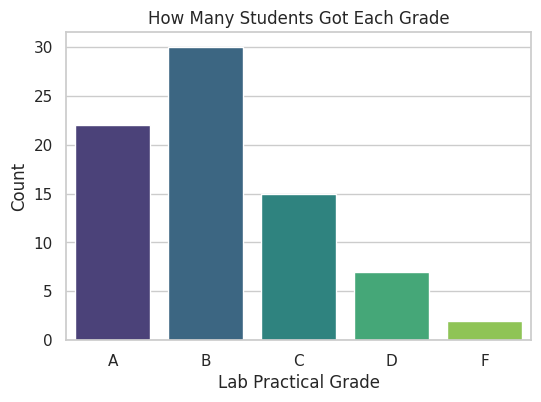

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Bar plot: count of each grade
plt.figure(figsize=(6, 4))
sns.countplot(x="lab_practical_grade", data=df, order=["A", "B", "C", "D", "F"], palette="viridis")
plt.title("How Many Students Got Each Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("Count")
plt.show()


Most students received A’s or B’s. Grades like D and F were rare, which shows that our dataset is imbalanced

## Study Time vs. Grade (Box Plot)

Next, we looked at how many hours students studied each week and whether that had any connection to their final grade.


/tmp/ipykernel_27029/1298499061.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="lab_practical_grade", y="study_hours_per_week", data=df, order=["A", "B", "C", "D", "F"], palette="pastel")


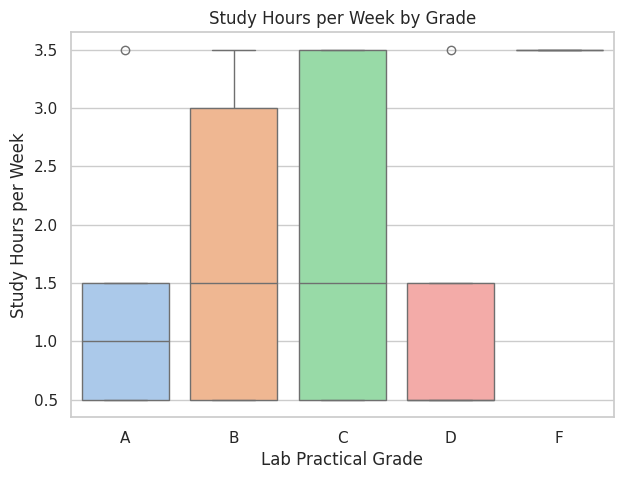

In [10]:
# Boxplot: study hours vs grade
plt.figure(figsize=(7, 5))
sns.boxplot(x="lab_practical_grade", y="study_hours_per_week", data=df, order=["A", "B", "C", "D", "F"], palette="pastel")
plt.title("Study Hours per Week by Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("Study Hours per Week")
plt.show()


**What we saw:**  
C students studied more than A students on average, which was unexpected. This shows that more hours spent studying doesn’t necessarily mean a higher grade — there may be other variables influencing performance.


While in class, we have used full pairplots - we decided that the pairplot wouldn't be too useful in this case, and a bit overwhelming. We did initially have one in here, but it was way too cluttered to look at anything potentially meaningful. Instead, we broke it down into smaller plots that compare one feature at a time across different grade outcomes. Here are some more of the plots we looked at besides the previous ones: 

### Confidence Before the Practical

This plot shows how confident students felt in their lab skills going into the practical — and how that confidence relates to their final grade.


/tmp/ipykernel_27029/2862446979.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="lab_practical_grade", y="confidence_before_practical", data=df, order=["A", "B", "C", "D", "F"], palette="coolwarm")


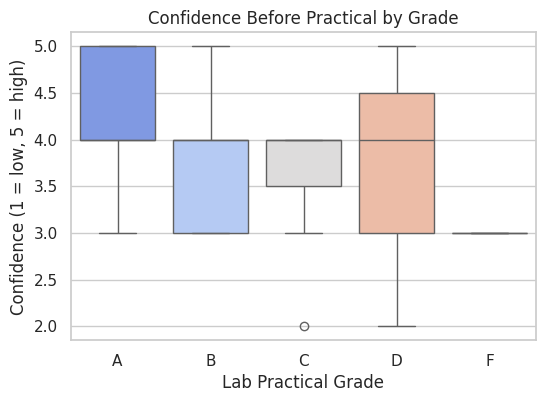

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="lab_practical_grade", y="confidence_before_practical", data=df, order=["A", "B", "C", "D", "F"], palette="coolwarm")
plt.title("Confidence Before Practical by Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("Confidence (1 = low, 5 = high)")
plt.show()


**What we saw:**  
A students tended to be more confident overall, while F students showed the lowest confidence. This makes  somehwat sense, and suggests confidence could be one of the more predictive features. We do have to account for the fact that there are not many F students though.

This is actually funny because there is a concept in cognitive psychology for this, so it was cool to see it actually happen in our data.

### Anxiety About the Practical

Now we’re looking at how nervous students were before the exam. This might show if anxiety had any pattern tied to lower performance.


/tmp/ipykernel_27029/1789984229.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="lab_practical_grade", y="anxiety_about_practical", data=df, order=["A", "B", "C", "D", "F"], palette="rocket")


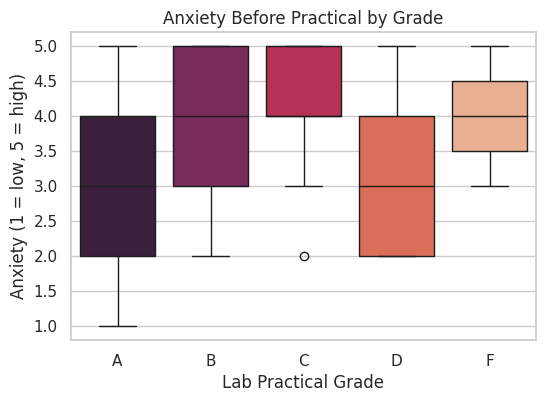

In [17]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="lab_practical_grade", y="anxiety_about_practical", data=df, order=["A", "B", "C", "D", "F"], palette="rocket")
plt.title("Anxiety Before Practical by Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("Anxiety (1 = low, 5 = high)")
plt.show()



*What we saw* 

A students had some of the **lowest anxiety levels**, while students who got C, D, or F generally had higher anxiety. It’s not a perfect pattern, but there’s a clear enough shift that it might be relevant when modeling. Basically, lower anxiety seems to *help*, or at least it isn’t hurting.

Also kind of funny — this lines up with the **Optimal Arousal** concept in psychology. A little stress can help, but too much can possibly hurt performance. The A group might’ve had just enough stress to stay focused without freaking out.


### ChatGPT Helpfulness Rating

We asked students how helpful they found ChatGPT while studying. Let’s see how that breaks down by grade.


/tmp/ipykernel_27029/501991702.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="lab_practical_grade", y="helpfulness_chatgpt", data=df, order=["A", "B", "C", "D", "F"], palette="mako")


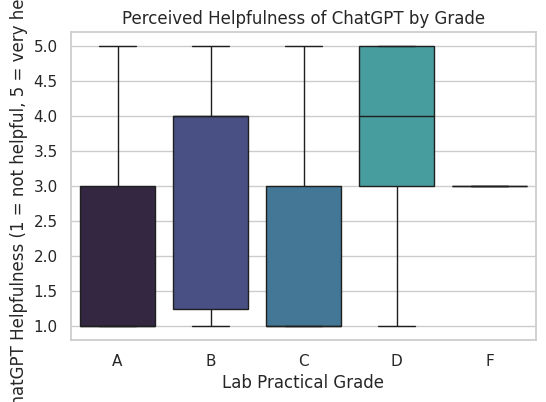

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="lab_practical_grade", y="helpfulness_chatgpt", data=df, order=["A", "B", "C", "D", "F"], palette="mako")
plt.title("Perceived Helpfulness of ChatGPT by Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("ChatGPT Helpfulness (1 = not helpful, 5 = very helpful)")
plt.show()


**What we saw:**  
This was not what we expected. A students rated ChatGPT as less helpful than D students, who gave it the highest scores overall. B students landed somewhere in the middle.

Everything’s a little all over the place here though, so it’s probably not one of our strongest predictors.


### Lab Practice Times vs. Grade

We also looked at how many times students came into the lab outside of class to practice techniques — and whether that had any connection to their final grade.


/tmp/ipykernel_27029/369750630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="lab_practical_grade", y="lab_practice_times", data=df, order=["A", "B", "C", "D", "F"], palette="crest")


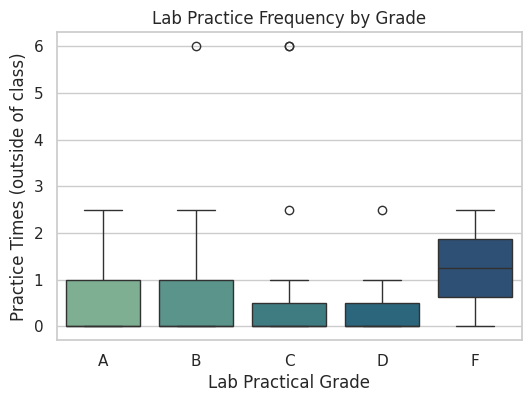

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="lab_practical_grade", y="lab_practice_times", data=df, order=["A", "B", "C", "D", "F"], palette="crest")
plt.title("Lab Practice Frequency by Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("Practice Times (outside of class)")
plt.show()


**What we saw:**  
Interestingly, the two F students actually reported the **highest practice frequency** — even more than the A students. But with such a small number of F responses, we can’t really take this as meaningful.

At best, it shows that more practice didn’t always lead to better grades. It might reflect students trying to compensate late, or it could just be random. Either way, this feature probably won’t be a strong predictor.



## Model Setup

Now that we’ve cleaned and explored the data, it’s time to set up our models.

We’re starting with three base models:

- **Logistic Regression**
- **Decision Tree**
- **Random Forest**

These will be trained using the **full feature set**, without any tuning or feature selection yet. That way, we can see how they perform right out of the box and get a true baseline.

Once we’ve seen what they can do, we’ll move on to:
- **Hyperparameter tuning**
- **Feature selection**
- And finally, a Gradient Boosting model .

We’re using a **70/30 train-test split** to give ourselves more test data. Since we only have 82 responses total, this lets us evaluate model performance on a slightly larger test set without sacrificing too much training data.

First Model: Logistic Regression

We started with **Logistic Regression** to get a baseline. It gives us a decent first look at how well the full set of features can predict a student’s lab grade — without doing any tuning or filtering yet.

Even though it’s usually used for binary classification, it can handle multiple classes like A/B/C/D/F using a method called **one-vs-rest**, where the model basically learns to separate each grade from all the others.

Accuracy: 34.78%
Classification Report:
              precision    recall  f1-score   support

           A       0.50      0.57      0.53         7
           B       0.43      0.33      0.38         9
           C       0.12      0.25      0.17         4
           D       0.00      0.00      0.00         2
           F       0.00      0.00      0.00         1

    accuracy                           0.35        23
   macro avg       0.21      0.23      0.21        23
weighted avg       0.34      0.35      0.34        23



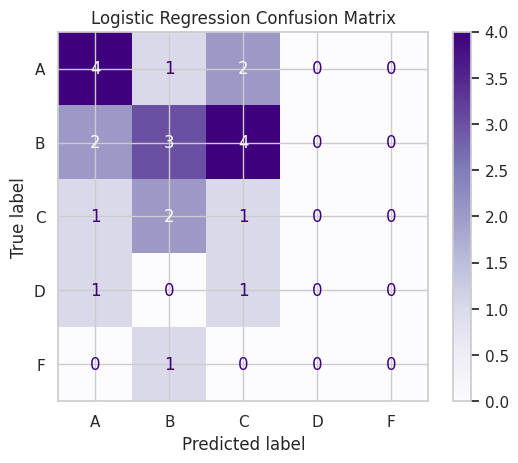

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define features and target
X = df.drop(columns=["lab_practical_grade"])
y = df["lab_practical_grade"]

# Step 2: Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Step 3: Train the logistic regression model
logreg = LogisticRegression(max_iter=10000, solver="lbfgs")
logreg.fit(X_train, y_train)

# Step 4: Make predictions
y_pred = logreg.predict(X_test)

# Step 5: Evaluate performance
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Step 6: Handle label mismatch in confusion matrix
labels_in_test = np.unique(np.concatenate([y_test, y_pred]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred, labels=labels_in_test),
    display_labels=labels_in_test
).plot(cmap="Purples")

plt.title("Logistic Regression Confusion Matrix")
plt.show()


### 📉 Logistic Regression – Baseline Results

**Accuracy:** 34.78%  
**Test Set Size:** 23 students

**What we saw:**  
This baseline model struggled to get solid predictions across the board. It did okay with A and B students, but once it got to the lower grades, performance dropped off fast. C, D, and F grades were rarely predicted correctly — and in some cases (like F), not at all.

This makes sense though. Logistic Regression is a **linear model**, and it’s not great at capturing messy or overlapping patterns — especially when the classes are imbalanced like this. But it still gives us a decent baseline to compare against when we try more complex models next.


Baseline Model: Decision Tree

Next up, we’re trying a **Decision Tree Classifier**. This model is a bit more flexible than Logistic Regression because it doesn’t assume linear relationships between features — it splits the data based on feature thresholds instead.

We're still using:
- The **full feature set**
- No feature selection or scaling
- No tuning yet (this is the default version)

This should give us an idea of how well a simple non-linear model handles the grade prediction task before we try to optimize anything.

Accuracy (Decision Tree): 34.78%
Classification Report (Decision Tree):
              precision    recall  f1-score   support

           A       0.43      0.43      0.43         7
           B       0.57      0.44      0.50         9
           C       0.00      0.00      0.00         4
           D       0.25      0.50      0.33         2
           F       0.00      0.00      0.00         1

    accuracy                           0.35        23
   macro avg       0.25      0.27      0.25        23
weighted avg       0.38      0.35      0.36        23



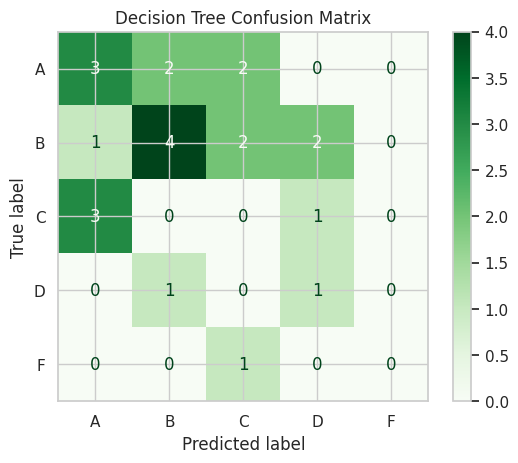

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Train a basic decision tree using the same split
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Make predictions
y_pred_tree = tree.predict(X_test)

# Evaluate performance
print(f"Accuracy (Decision Tree): {accuracy_score(y_test, y_pred_tree)*100:.2f}%")
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_tree, zero_division=0))

# Confusion Matrix
labels_in_tree_test = np.unique(np.concatenate([y_test, y_pred_tree]))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_tree, labels=labels_in_tree_test),
    display_labels=labels_in_tree_test
).plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.show()


### Decision Tree – Baseline Results

**Accuracy:** 34.78%  
**Test Set Size:** 23 students

**What we saw:**  
This model didn’t really improve over logistic regression. A and B grades had decent performance, but the rest were hit or miss. C and F grades weren’t predicted at all, and even though D had better recall, it was only based on 2 students.

Decision Trees are more flexible than logistic regression, but without any tuning, they’re also more prone to overfitting — especially with small datasets like this. Overall, this gave us a similar baseline to work from, but it didn’t really solve the class imbalance issue or help with lower-performing students.


## Baseline Model: Random Forest

Next we’re trying **Random Forest**, which builds a bunch of decision trees and averages their predictions. This helps reduce overfitting and usually performs better than a single tree, especially on noisy data.

We’re still using:
- The **full feature set**
- No feature selection
- No tuning (just the default 100 trees)

This will show us whether combining trees gives a noticeable boost over Logistic Regression and the plain Decision Tree.


Accuracy (Random Forest): 43.48%
Classification Report (Random Forest):
              precision    recall  f1-score   support

           A       0.60      0.43      0.50         7
           B       0.41      0.78      0.54         9
           C       0.00      0.00      0.00         4
           D       0.00      0.00      0.00         2
           F       0.00      0.00      0.00         1

    accuracy                           0.43        23
   macro avg       0.20      0.24      0.21        23
weighted avg       0.34      0.43      0.36        23



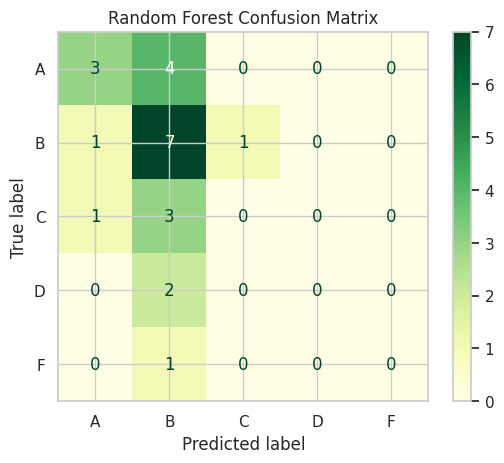

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Train baseline random forest
forest = RandomForestClassifier(random_state=42, n_estimators=100)
forest.fit(X_train, y_train)

# Make predictions
y_pred_forest = forest.predict(X_test)

# Evaluate performance
print(f"Accuracy (Random Forest): {accuracy_score(y_test, y_pred_forest)*100:.2f}%")
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_forest, zero_division=0))

# Confusion Matrix
labels_in_forest_test = np.unique(np.concatenate([y_test, y_pred_forest]))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_forest, labels=labels_in_forest_test),
    display_labels=labels_in_forest_test
).plot(cmap="YlGn")

plt.title("Random Forest Confusion Matrix")
plt.show()


Random Forest – Baseline Results

**Accuracy:** 43.48%  
**Test Set Size:** 23 students

**What we saw:**  
Random Forest gave us our best accuracy so far, jumping up to about 43%. It did especially well with B students, getting a **recall of 78%**, which is solid. A students were also predicted decently, but once again, the lower grades (C, D, F) didn’t come through — they were either missed entirely or misclassified as something else.

## Baseline Model: Gradient Boosting

For our final baseline model, we’re testing out **Gradient Boosting** — a more advanced technique that builds trees one at a time, with each new tree trying to correct the mistakes made by the ones before it.

This model is often better at capturing subtle patterns than Random Forest, but it can also be slower and more sensitive to tuning.

We’re still using:
- The **full feature set**
- No tuning or feature selection (just default settings)

Let’s see how it performs right out of the box.


Accuracy (Gradient Boosting): 39.13%
Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           A       0.67      0.57      0.62         7
           B       0.36      0.44      0.40         9
           C       0.00      0.00      0.00         4
           D       0.00      0.00      0.00         2
           F       1.00      1.00      1.00         1

    accuracy                           0.39        23
   macro avg       0.41      0.40      0.40        23
weighted avg       0.39      0.39      0.39        23



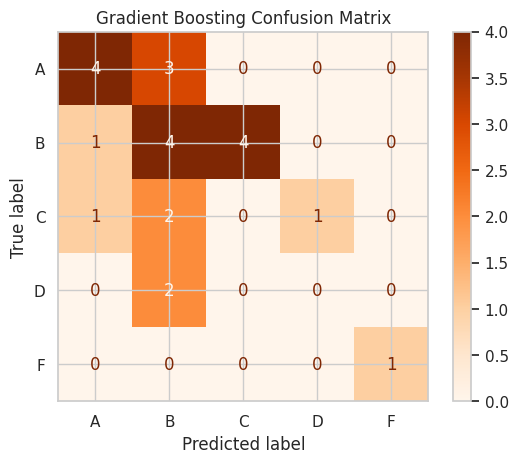

In [25]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Train baseline gradient boosting model
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb.predict(X_test)

# Evaluate performance
print(f"Accuracy (Gradient Boosting): {accuracy_score(y_test, y_pred_gb)*100:.2f}%")
print("Classification Report (Gradient Boosting):")
print(classification_report(y_test, y_pred_gb, zero_division=0))

# Confusion Matrix
labels_in_gb_test = np.unique(np.concatenate([y_test, y_pred_gb]))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_gb, labels=labels_in_gb_test),
    display_labels=labels_in_gb_test
).plot(cmap="Oranges")

plt.title("Gradient Boosting Confusion Matrix")
plt.show()


### 🚀 Gradient Boosting – Baseline Results

**Accuracy:** 39.13%  
**Test Set Size:** 23 students

**What we saw:**  
This model actually did okay with A students and got the one F completely right (not that it counts for much since there’s literally one). B was alright-ish, and C and D got ignored like usual.

Overall, not bad for a first run. Gradient Boosting could do better once it’s tuned, so this is not a bad start. We’ll probably get better results once we clean up the features and play with the parameters a bit.


## Baseline Model Comparison

Now that we’ve run all four models with no tuning or feature selection, here’s a quick comparison of how they stacked up. This helps us figure out which ones are already doing okay and which ones might be worth tuning later.

Keep in mind, all of these were trained on the **full dataset** with no scaling or feature cleanup — so they’re just raw baseline performances.


In [26]:
import pandas as pd

baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        34.78,
        34.78,
        43.48,
        39.13
    ],
    "Best Prediction Area": [
        "A (decent), B (low)",
        "B (ok), D (some recall)",
        "B (78% recall)",
        "A (strong), F (100% but 1 student)"
    ]
})

baseline_results


,Model,Accuracy,Best Prediction Area
0,Logistic Regression,34.78,"A (decent), B (low)"
1,Decision Tree,34.78,"B (ok), D (some recall)"
2,Random Forest,43.48,B (78% recall)
3,Gradient Boosting,39.13,"A (strong), F (100% but 1 student)"
